## 2.0 Data Preparation

### Loading the dataset and converting image to a numpy array. 

In [1]:
#Asked GPT to help fix the directory issue. 
import numpy as np
from PIL import Image
import os

base_dir = os.path.abspath("./images")
folder_names = os.listdir(base_dir)

image_data_gray = []
image_label = []

for folder_name in folder_names:
    folder_path = os.path.join(base_dir, folder_name)

    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)
        img = Image.open(image_path)
        img = img.resize((64, 64))
        
        img_gray = img.convert('L')
        img_array = np.array(img_gray)
        
        flatten_image = img_array.flatten() #Creating a 1D vector
        image_data_gray.append(flatten_image)
        image_label.append(folder_name)

image_data_gray = np.array(image_data_gray)
image_label = np.array(image_label)

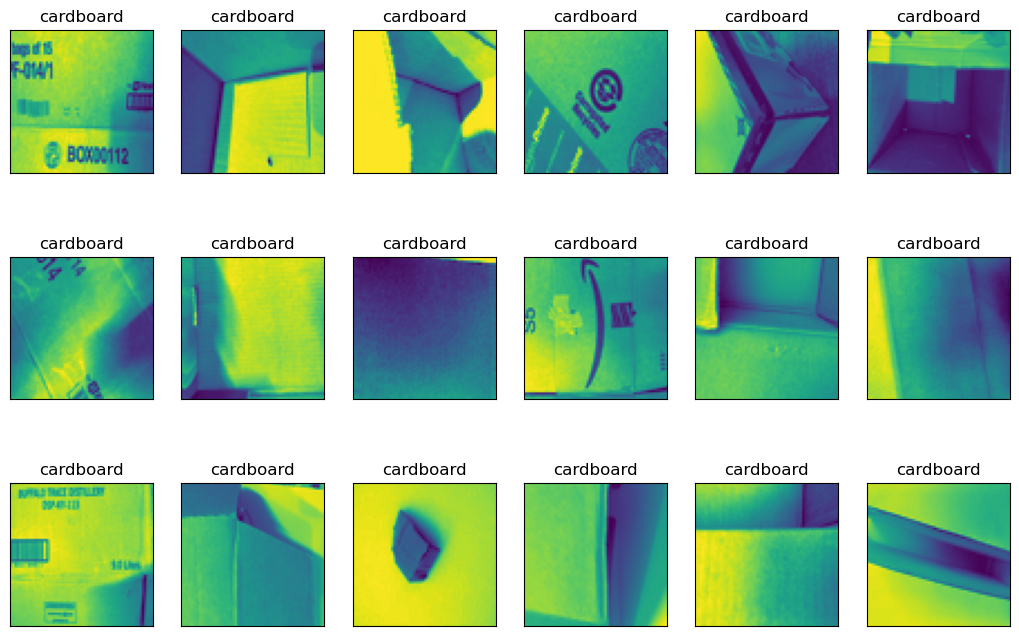

In [2]:
##This code block was taken from Eric Larson code notebook
import matplotlib.pyplot as plt

# a helper plotting function
def plot_gallery(images, titles, h, w, n_row=3, n_col=6):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.7 * n_col, 2.3 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)))
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

plot_gallery(image_data_gray, image_label, 64, 64)

## 4.0 Data Reduction

### 4.4 Feature Extraction Using Daisy

In [4]:
from skimage.feature import daisy
from skimage.io import imshow

daisy_features_list = []

for i, single_image in enumerate(image_data_gray):
    #Need to reshape the image for daisy
    single_image_reshape = single_image.reshape(64, 64)
    
    daisy_features = daisy(single_image_reshape,
                          step=4,        
                          radius=10,     
                          rings=2,       
                          histograms=6,  
                          orientations=8,
                          )
    
    flattened_daisy = daisy_features.flatten()
    daisy_features_list.append(flattened_daisy)

daisy_features_array = np.array(daisy_features_list)
print(f"Final DAISY features shape: {daisy_features_array.shape}")

Final DAISY features shape: (13901, 12584)


### Result. 

After performing feature extraction using Daisy with a step of 4, radius of 10, ring of 2, histrogram of 6, and orientation of 8, we got a shape of 13901 and 12584. The value of 13901 is expected as thats the total number of pictures from our dataset, and the value of 12584 indicates that Daisy was able to extra a lot of features from the photos. This indicates that Daisy was able to capture a lot of local gradient across each images, however it does come with an issue of overfitting since the dimensional is high. 

### 4.5 Finding if the extracted feature is useful for the creating a classifier

In [5]:
#Encoding the labels to numeric

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

numeric_label = label_encoder.fit_transform(image_label)

print(numeric_label)

[0 0 0 ... 5 5 5]


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

daisy_train, daisy_test, label_train, label_test = train_test_split(daisy_features_array, numeric_label, test_size=0.2, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(daisy_train, label_train)
label_pred = knn.predict(daisy_test)

print("Accuracy: ", accuracy_score(label_test, label_pred))
print(classification_report(label_test, label_pred, target_names=label_encoder.classes_))

Accuracy:  0.5026968716289104
              precision    recall  f1-score   support

   cardboard       0.43      0.55      0.49       449
       glass       0.60      0.50      0.54       506
       metal       0.44      0.63      0.52       389
       paper       0.52      0.39      0.45       478
     plastic       0.64      0.44      0.52       479
       trash       0.47      0.53      0.50       480

    accuracy                           0.50      2781
   macro avg       0.52      0.51      0.50      2781
weighted avg       0.52      0.50      0.50      2781



### Result

Looking at the result of KNN classifier, we did not get a good result with a neighbor of 3. The accuracy was 50%, and looking at each class precision only the glass, and plastic had good values. Indicating that knn was able to classify glass, and plastic better than the other group. This could be because the we resize the image to a 64x64 pixel, and doing so we might have loss some details that could help classify the image. 

As such for the feature extraction method does not look promising if we are keeping it as a 64x64 pixel size. It could perform better if we had more pixel so that we can extract more useful features, or tunning the parameter of daisy to extract the feature, but keeping the parameter of Knn and the daisy the same as what we have is not the best. 

unique [0 1 2 3 4 5]


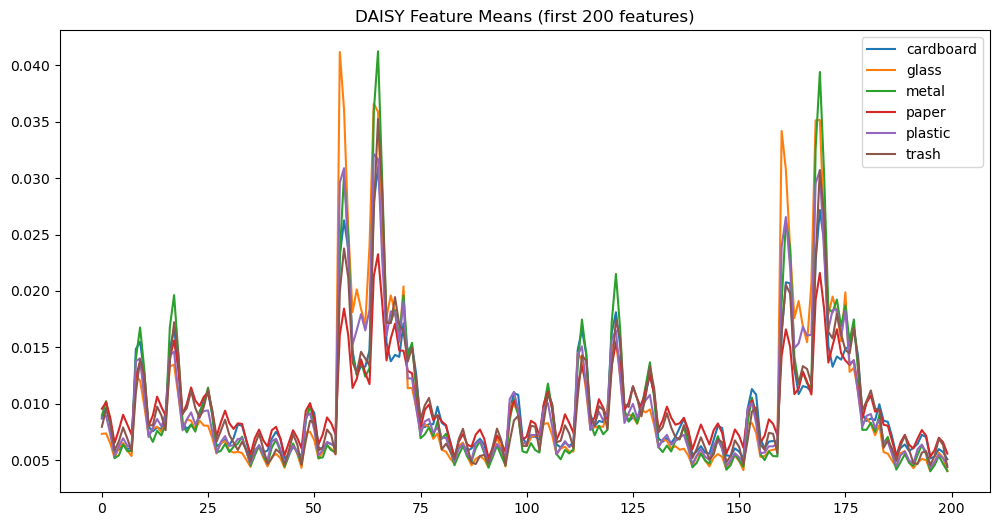

In [10]:
import matplotlib.pyplot as plt

means = []

print("unique", np.unique(numeric_label))

for class_names in np.unique(numeric_label):
  class_feature = daisy_features_array[numeric_label == class_names]
  class_mean = class_feature.mean(axis=0)
  means.append(class_mean)
  
means = np.array(means)

plt.figure(figsize=(12,6))
for i, mean_vec in enumerate(means[:6]):
    plt.plot(mean_vec[:200], label=f"{label_encoder.classes_[i]}")
plt.legend()
plt.title("DAISY Feature Means (first 200 features)")
plt.show()

### Graph Analysis. 

From the graph, we can see that daisy was able to extract information that were different within the class. From this result, we can see that daisy was able to extract more information form photos label as glass or metal and other labels showed some overlap. This is because plastic, paper, and cardboard have similar texture to one another, which could cause daisy to not extract as much information out compared to glass and metal with their reflective, and or uneven edges. 

## 4.0 Exceptional Work

C:\Users\David\AppData\Local\Temp\ipykernel_26592\3101653245.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([within_scores, between_scores], labels=["within-class", "between-class"])


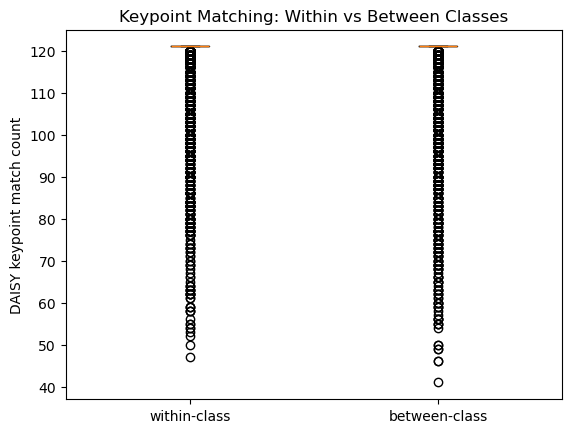

In [39]:
#Used gpt to handle repeated images being selected between loop interactions
from sklearn.metrics import pairwise_distances_argmin_min

def compute_daisy_descriptors(img, step, radius):
    side = int(np.sqrt(img.shape[0]))
    img = img.reshape(side, side)
  
    desc = daisy(
        img,
        step=step,
        radius=radius,
        rings=2,
        histograms=6,
        orientations=8,
        )
    
    return desc.reshape(-1, desc.shape[-1])


def key_point_matching(img1, img2, threshold=0.15):
    daisy1, daisy2 = compute_daisy_descriptors(img1, 4, 10), compute_daisy_descriptors(img2, 10, 10)
    _, distance = pairwise_distances_argmin_min(daisy1, daisy2)
    matches = np.sum(distance < threshold)
    return matches


within_scores = []
between_scores = []

unique_labels = np.unique(numeric_label)

within_used = set()
between_used = set()

for _ in range(5000):
    random_class = np.random.choice(unique_labels)
    index = np.where(numeric_label == random_class)[0]
    i, j = np.random.choice(index, 2, replace=False)
    
    pair = tuple(sorted((i, j)))
    if pair not in within_used:
      within_used.add(pair)
      within_scores.append(key_point_matching(image_data_gray[i], image_data_gray[j]))
        
    
    random_label_1, random_label_2 = np.random.choice(unique_labels, 2, replace=False)
    i = np.random.choice(np.where(numeric_label == random_label_1)[0])
    j = np.random.choice(np.where(numeric_label == random_label_2)[0])
    
    pair = tuple(sorted((i, j)))
    if pair not in between_used:
        between_used.add(pair)
        between_scores.append(key_point_matching(image_data_gray[i], image_data_gray[j]))
    
plt.boxplot([within_scores, between_scores], labels=["within-class", "between-class"])
plt.ylabel("DAISY keypoint match count")
plt.title("Keypoint Matching: Within vs Between Classes")
plt.show()
    

### Boxplot analysis. 

We first extract features using daisy, and from the extracted feature we then calculate the pairwise distance between the two extracted daisy, and if we calculate the distance is less than 0.15, we would considered as match. From there, we then run a loop 5000, and each time we ensure that we pick unique images for comparison by using set to keep track of the images. 

From the result of the boxplot, we can see that the distribution between within class, and between class are the almost the same. This indicates that daisy descriptors did not provide strong matches between key point in the dataset. This could be due to various reason from the dataset, to the parameters we choose when computing daisy. As such, we can conclude that the key matching did not perform well on this dataset. Increasing the pixel size could provide better result, but it is expensive to run daisy on the entire dataset. 